# 🧪 Lab 2 Template — MLP for Image Classification

This is your starting point for **both** required notebooks:

1. Duplicate this file and rename it **`lab2_cifar10.ipynb`** — set `DATASET = "cifar10"` below, and complete Part A.
2. Duplicate it again and rename it **`lab2_fashion_mnist.ipynb`** — set `DATASET = "fashion_mnist"`, and complete Part B.
3. *(Bonus, optional)* duplicate once more for `"cifar100"` if you're attempting the extra-credit extension.

Cells marked **`# YOUR CODE STARTS HERE`** / **`# YOUR CODE ENDS HERE`** are the parts you need to fill in — this is the same convention used in the `propagate()` / `optimize()` / `model()` exercises. Everything else is provided so you can focus on the actual learning objectives (preprocessing, model definition, and training).

**Environment**: this notebook runs unmodified in either setup described in the lab handout — the official book Docker container, or a local pip/conda environment. See Section 4 of the assignment for both options.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers, utils, datasets

# If you are running inside the book's official Docker container, this helper
# gives nicer image grids. If it isn't available (e.g. local environment),
# we fall back to a simple matplotlib version so the notebook still runs.
try:
    from notebooks.utils import display
except ImportError:
    def display(images, labels=None, n=10, cmap=None):
        fig = plt.figure(figsize=(15, 3))
        for i in range(min(n, len(images))):
            ax = fig.add_subplot(1, n, i + 1)
            ax.axis("off")
            img = images[i]
            if img.shape[-1] == 1:
                ax.imshow(img.squeeze(), cmap=cmap or "gray")
            else:
                ax.imshow(img)
            if labels is not None:
                ax.set_title(str(labels[i]), fontsize=9)
        plt.show()

## 0. Choose Your Dataset

In [2]:
# Set this to "cifar10", "fashion_mnist", or "cifar100" (bonus)
DATASET = "fashion_mnist"

DATASET_INFO = {
    "cifar10": {
        "num_classes": 10,
        "loader": datasets.cifar10.load_data,
        "class_names": np.array([
            "airplane", "automobile", "bird", "cat", "deer",
            "dog", "frog", "horse", "ship", "truck",
        ]),
    },
    "fashion_mnist": {
        "num_classes": 10,
        "loader": datasets.fashion_mnist.load_data,
        "class_names": np.array([
            "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
        ]),
    },
    "cifar100": {
        "num_classes": 100,
        "loader": datasets.cifar100.load_data,
        "class_names": None,  # 100 fine-grained classes — see Keras docs if you want names
    },
}

NUM_CLASSES = DATASET_INFO[DATASET]["num_classes"]
CLASSES = DATASET_INFO[DATASET]["class_names"]
print(f"Dataset: {DATASET}  |  NUM_CLASSES: {NUM_CLASSES}")

Dataset: fashion_mnist  |  NUM_CLASSES: 10


## 1. Prepare the Data

**Hints:**
- Pixel values need to be scaled from `[0, 255]` to `[0, 1]` — same normalization as the reference notebook.
- CIFAR datasets already come back with shape `(N, 32, 32, 3)`. **Fashion-MNIST comes back as `(N, 28, 28)`** — no channel dimension — so you'll need to add one before it can be fed to the model.
- Labels need to be one-hot encoded with `utils.to_categorical`, exactly as in the reference notebook.

In [3]:
(x_train, y_train), (x_test, y_test) = DATASET_INFO[DATASET]["loader"]()

print("Raw shapes:", x_train.shape, y_train.shape, x_test.shape, y_test.shape)

Raw shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [4]:
# TODO:
#   1) Cast x_train / x_test to float32 and scale to [0, 1]
#   2) If the images have no channel dimension (Fashion-MNIST), reshape to add one:
#        x_train.reshape(-1, 28, 28, 1)
#   3) One-hot encode y_train / y_test using utils.to_categorical and NUM_CLASSES
# (~4-6 lines of code)

# YOUR CODE STARTS HERE
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_test = utils.to_categorical(y_test, NUM_CLASSES)
# YOUR CODE ENDS HERE

print("Prepared shapes:", x_train.shape, y_train.shape, x_test.shape, y_test.shape)
assert x_train.max() <= 1.0 and x_train.min() >= 0.0, "Pixel values should be scaled to [0, 1]"
assert y_train.shape[-1] == NUM_CLASSES, "Labels should be one-hot encoded to NUM_CLASSES"
assert x_train.ndim == 4, "Images should have a channel dimension, e.g. (N, H, W, C)"
print("Shape checks passed.")

Prepared shapes: (60000, 28, 28, 1) (60000, 10) (10000, 28, 28, 1) (10000, 10)
Shape checks passed.


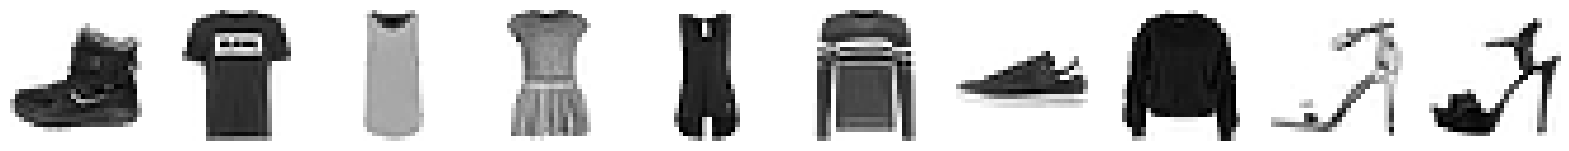

['Ankle boot' 'T-shirt/top' 'T-shirt/top' 'Dress' 'T-shirt/top' 'Pullover'
 'Sneaker' 'Pullover' 'Sandal' 'Sandal']


In [6]:
# Sanity check — look at a few training examples before you build anything
sample_labels = (
    CLASSES[np.argmax(y_train[:10], axis=-1)]
    if CLASSES is not None
    else np.argmax(y_train[:10], axis=-1)
)
#display function has no parameter named labels, so i have removed this argument from function and printed sample_labels seperately
display(x_train[:10])
print(sample_labels)

## 2. Build the Model

Use the same architecture as the reference notebook: `Flatten → Dense(200, relu) → Dense(150, relu) → Dense(NUM_CLASSES, softmax)`.

**Hint:** `input_layer = layers.Input(x_train.shape[1:])` will automatically pick up the correct input shape for whichever dataset you selected above, so you don't need to hardcode `(32, 32, 3)` or `(28, 28, 1)`.

In [7]:
# TODO: build the MLP
#   - input_layer = layers.Input(...)
#   - x = layers.Flatten()(input_layer)
#   - x = layers.Dense(200, activation="relu")(x)
#   - x = layers.Dense(150, activation="relu")(x)
#   - output_layer = layers.Dense(NUM_CLASSES, activation=...)(x)   <- which activation belongs here?
#   - model = models.Model(input_layer, output_layer)
# (~6 lines of code)

# YOUR CODE STARTS HERE
input_layer = layers.Input(x_train.shape[1:])

x = layers.Flatten()(input_layer)
x = layers.Dense(200, activation="relu")(x)
x = layers.Dense(150, activation="relu")(x)

output_layer = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(input_layer, output_layer)
# YOUR CODE ENDS HERE

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 200)               157000    
                                                                 
 dense_1 (Dense)             (None, 150)               30150     
                                                                 
 dense_2 (Dense)             (None, 10)                1510      
                                                                 
Total params: 188,660
Trainable params: 188,660
Non-trainable params: 0
_________________________________________________________________


2026-08-31 18:27:25.670712: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-08-31 18:27:25.670887: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-08-31 18:27:25.670911: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (361dfff0c5b1): /proc/driver/nvidia/version does not exist
2026-08-31 18:27:25.671265: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 3. Train the Model

**Hint:** use the Adam optimizer with `learning_rate=0.0005` and `categorical_crossentropy` loss — same as the reference notebook.

In [8]:
# TODO: compile the model
#   opt = optimizers.Adam(learning_rate=...)
#   model.compile(loss=..., optimizer=opt, metrics=["accuracy"])
# (~2 lines of code)

# YOUR CODE STARTS HERE
opt = optimizers.Adam(learning_rate=0.0005)
model.compile(
    loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"]
)
# YOUR CODE ENDS HERE

In [9]:
# TODO: fit the model
#   model.fit(x_train, y_train, batch_size=32, epochs=10, shuffle=True)
# (~1 line of code)

# YOUR CODE STARTS HERE
model.fit(x_train, y_train, batch_size=32, epochs=10, shuffle=True)
# YOUR CODE ENDS HERE

Epoch 1/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4935 - accuracy: 0.8249
Epoch 2/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.3598 - accuracy: 0.8691
Epoch 3/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.3235 - accuracy: 0.8809
Epoch 4/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.3005 - accuracy: 0.8883
Epoch 5/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2811 - accuracy: 0.8954
Epoch 6/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2658 - accuracy: 0.9003
Epoch 7/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2525 - accuracy: 0.9050
Epoch 8/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2417 - accuracy: 0.9087
Epoch 9/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2320 - accuracy: 0.9126
Epoch 10/10
1875/1875 [==============================] - 3s 1ms/step - loss: 0.221

## 4. Evaluate

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 [==============================] - 0s 906us/step - loss: 0.3300 - accuracy: 0.8876
Test loss: 0.3300
Test accuracy: 0.8876


313/313 [==============================] - 0s 1ms/step


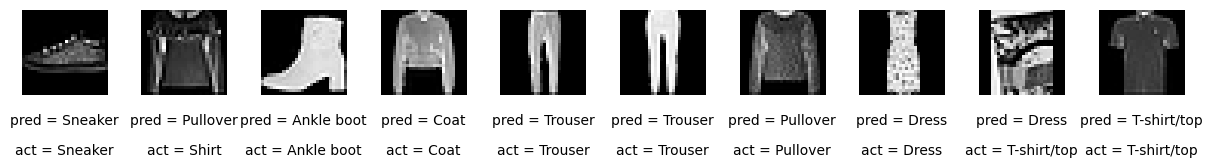

In [11]:
preds = model.predict(x_test)

n_to_show = 10
indices = np.random.choice(range(len(x_test)), n_to_show)

fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    img = x_test[idx]
    pred_label = CLASSES[np.argmax(preds[idx])] if CLASSES is not None else np.argmax(preds[idx])
    true_label = CLASSES[np.argmax(y_test[idx])] if CLASSES is not None else np.argmax(y_test[idx])

    ax = fig.add_subplot(1, n_to_show, i + 1)
    ax.axis("off")
    ax.text(0.5, -0.35, "pred = " + str(pred_label), fontsize=10, ha="center", transform=ax.transAxes)
    ax.text(0.5, -0.7, "act = " + str(true_label), fontsize=10, ha="center", transform=ax.transAxes)
    ax.imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)

## 5. Reflection (for your write-up)

Answer these in `lab2_writeup.pdf` / `lab2_writeup.md`, not here — but it's worth jotting quick notes as you go:

- What was your final test accuracy and test loss for this dataset?
- Which classes did the model confuse most often, based on the sample predictions above?
- How does this dataset's accuracy compare to the other dataset(s) you trained on? Why do you think that is — consider image complexity, color vs. grayscale, and how visually similar the classes are to each other.